# Car Price Prediction Using Machine Learning

## Objective
To build a regression model that predicts the selling price of a used car based on various features such as age, fuel type, transmission type, and kilometers driven.

Import Libraries

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

Load Dataset

In [5]:
df = pd.read_csv("/content/CAR DETAILS FROM CAR DEKHO.csv")

df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


EDA

In [6]:
df.shape

(4340, 8)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [8]:
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [9]:
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


Checking for duplicates

In [10]:
df.duplicated().sum()

np.int64(763)

Removing duplicates

In [11]:
df.drop_duplicates(inplace=True)

Handle Inconsistent Categories

In [12]:
df["fuel"] = df["fuel"].str.title()
df["seller_type"] = df["seller_type"].str.title()
df["transmission"] = df["transmission"].str.title()

Feature Engineering

In [13]:
current_year = 2025

df["Car_Age"] = current_year - df["year"]

In [14]:
df["Brand"] = df["name"].apply(
    lambda x: x.split()[0]
)

In [15]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,Car_Age,Brand
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,18,Maruti
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,18,Maruti
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,13,Hyundai
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,8,Datsun
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,11,Honda


Two new features were created:
1. Car Age
2. Brand

EDA

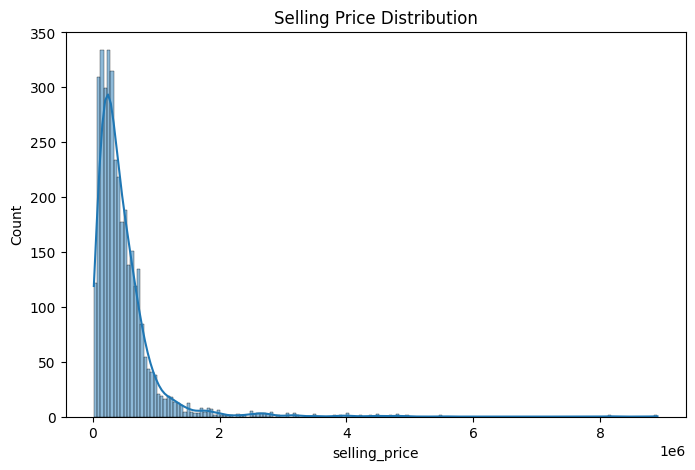

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["selling_price"],
    kde=True
)

plt.title("Selling Price Distribution")

plt.show()

Most cars are concentrated in the lower price range.

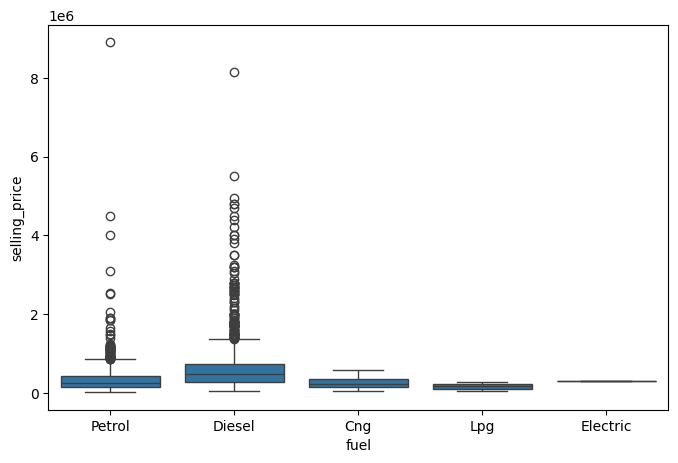

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="fuel",
    y="selling_price",
    data=df
)

plt.show()

Diesel vehicles tend to have higher selling prices.

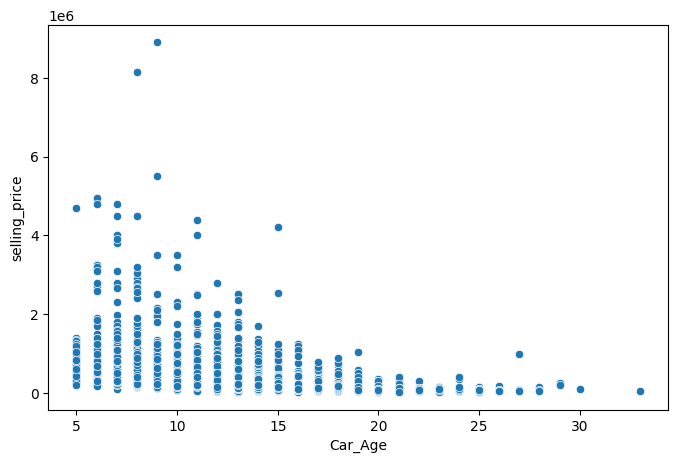

In [18]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Car_Age",
    y="selling_price",
    data=df
)

plt.show()

Selling price decreases as vehicle age increases.

Drop Unnecessary Columns

In [19]:
df.drop(
    ["name","year"],
    axis=1,
    inplace=True
)

Encode Categorical Variables

In [20]:
df = pd.get_dummies(
    df,
    drop_first=True
)
df.head()

,selling_price,km_driven,Car_Age,fuel_Diesel,fuel_Electric,fuel_Lpg,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,...,Brand_Mercedes-Benz,Brand_Mitsubishi,Brand_Nissan,Brand_OpelCorsa,Brand_Renault,Brand_Skoda,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Brand_Volvo
0,60000,70000,18,False,False,False,True,True,False,True,...,False,False,False,False,False,False,False,False,False,False
1,135000,50000,18,False,False,False,True,True,False,True,...,False,False,False,False,False,False,False,False,False,False
2,600000,100000,13,True,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
3,250000,46000,8,False,False,False,True,True,False,True,...,False,False,False,False,False,False,False,False,False,False
4,450000,141000,11,True,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False


Correlation Heatmap

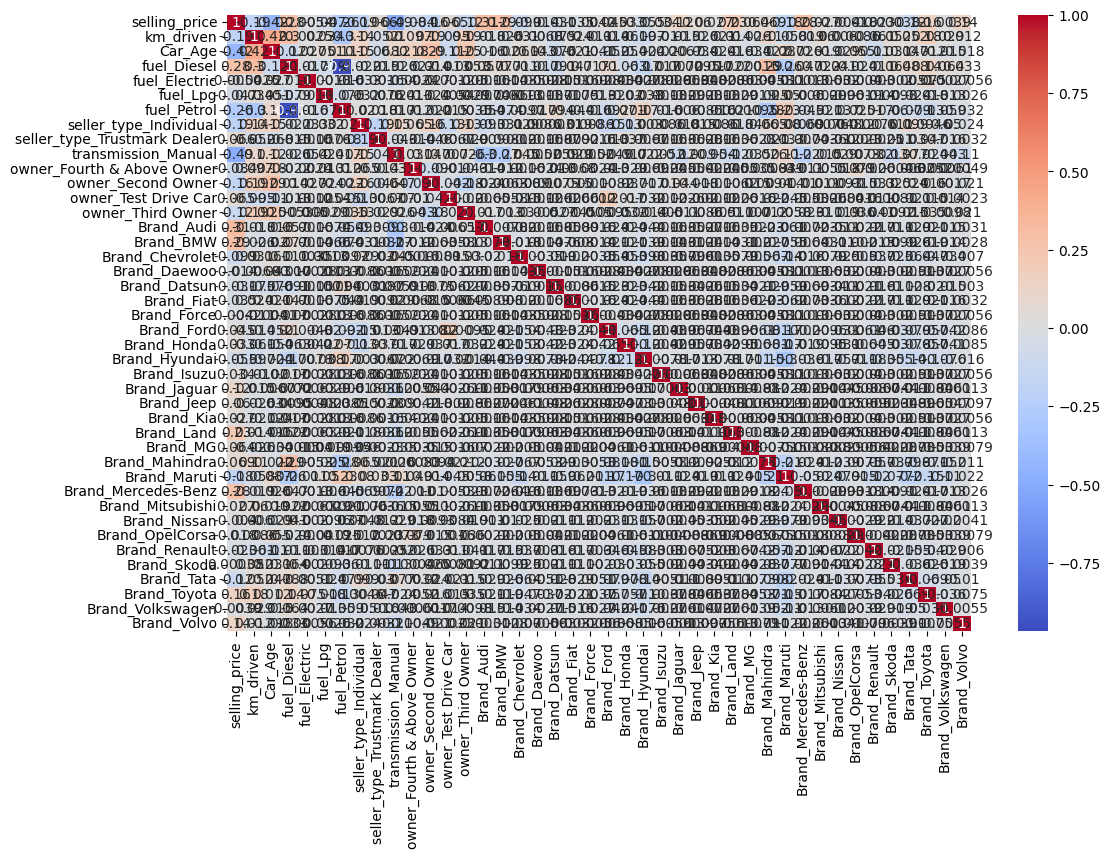

In [21]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

Several features show strong relationships with selling price.

Split Features and Target

In [22]:
X = df.drop(
    "selling_price",
    axis=1
)
y = df["selling_price"]

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Model 1
Linear Regression

In [23]:
lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

pred_lr = lr.predict(X_test)

Evaluation

In [24]:
print(
    "MAE:",
    mean_absolute_error(
        y_test,
        pred_lr
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            pred_lr
        )
    )
)

print(
    "R2:",
    r2_score(
        y_test,
        pred_lr
    )
)

MAE: 180194.9870217033
RMSE: 385606.0860978776
R2: 0.5384145989249838


Model 2
Random Forest Regressor

In [25]:
rf = RandomForestRegressor(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

pred_rf = rf.predict(X_test)

In [26]:
print(
    "MAE:",
    mean_absolute_error(
        y_test,
        pred_rf
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            pred_rf
        )
    )
)

print(
    "R2:",
    r2_score(
        y_test,
        pred_rf
    )
)

MAE: 158970.50799542782
RMSE: 368858.975989734
R2: 0.5776378252413277


Camparing Model

In [27]:
comparison = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Random Forest"
    ],
    "R2 Score":[
        r2_score(y_test,pred_lr),
        r2_score(y_test,pred_rf)
    ]
})

comparison

,Model,R2 Score
0,Linear Regression,0.538415
1,Random Forest,0.577638


Feature Importance

In [28]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
8,transmission_Manual,2.440251e-01
1,Car_Age,2.225210e-01
0,km_driven,1.414767e-01
2,fuel_Diesel,6.338277e-02
13,Brand_Audi,5.256728e-02
5,fuel_Petrol,5.003892e-02
27,Brand_Land,4.048589e-02
38,Brand_Toyota,3.746468e-02
6,seller_type_Individual,1.789629e-02
14,Brand_BMW,1.385167e-02


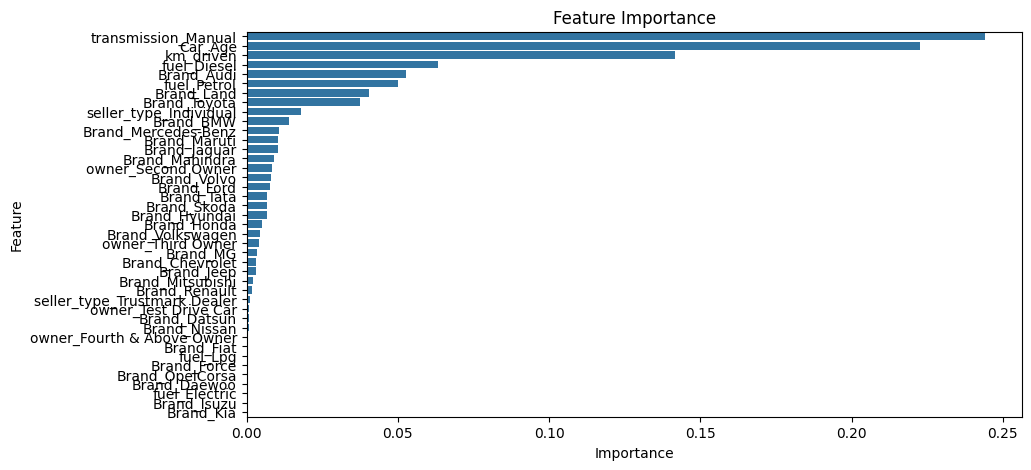

In [29]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title(
    "Feature Importance"
)

plt.show()

## Best Model Selection

Random Forest Regressor achieved the highest R² score and lowest prediction error.

Therefore it was selected as the final model.

## Conclusion

A machine learning model was developed to predict used car prices.

Key Findings:
- Car age significantly impacts selling price.
- Fuel type influences resale value.
- Random Forest Regressor outperformed Linear Regression.
- The model successfully predicts used car prices with high accuracy.